In [1]:
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=FutureWarning) # don't warn us about future package conflicts

In [2]:
import pandas as pd
import xarray as xr
import numpy as np
from datetime import datetime
# from healpix_plot import get_listed_colormap, get_diverging_colormap

### Read stats 

In [7]:
out_dir = '/Users/pacc275/local_documents/hackathon/updated_environmental_variables/'
df_prw_um = pd.read_parquet(out_dir+'UM/prw/')
df_rh500_um = pd.read_parquet(out_dir+'UM/hur/hur500/')
df_rh850_um = pd.read_parquet(out_dir+'UM/hur/hur850')
# df_omega500_um = pd.read_parquet(out_dir+'UM/omega/omega500')
df_omega850_um = pd.read_parquet(out_dir+'UM/omega')
df_tas_um = pd.read_parquet(out_dir+'UM/tas/')

df_prw_scream = pd.read_parquet(out_dir+'SCREAM/prw/')
df_rh500_scream = pd.read_parquet(out_dir+'SCREAM/rh500/')
df_rh850_scream = pd.read_parquet(out_dir+'SCREAM/rh850')
df_omega500_scream = pd.read_parquet(out_dir+'SCREAM/omega500')
df_omega850_scream = pd.read_parquet(out_dir+'SCREAM/omega850')
df_tas_scream = pd.read_parquet(out_dir+'SCREAM/tas/')

df_prw_icon = pd.read_parquet(out_dir+'ICON/prw/')
df_rh500_icon = pd.read_parquet(out_dir+'ICON/hur/hur500/')
df_rh850_icon = pd.read_parquet(out_dir+'ICON/hur/hur850')
df_omega500_icon = pd.read_parquet(out_dir+'ICON/omega/omega500')
df_omega850_icon = pd.read_parquet(out_dir+'ICON/omega/omega850')

In [10]:
## change scream output as percents 
df_rh850_icon['mean'] = df_rh850_icon['mean']*1000
df_rh500_icon['mean'] = df_rh500_icon['mean']*1000

In [8]:
## change scream output as percents 
df_rh500_scream['mean'] = df_rh500_scream['mean']*100
df_rh850_scream['mean'] = df_rh850_scream['mean']*100

In [38]:
df_omega500_icon['mean'].describe()

count    2.132676e+06
mean    -4.019195e-03
std      3.003456e-02
min     -3.729575e-01
25%     -2.071857e-02
50%     -3.259905e-03
75%      1.337575e-02
max      3.060292e-01
Name: mean, dtype: float64

In [40]:
df_omega850_um['mean'].describe()

count    2.855235e+06
mean    -6.943971e-02
std      1.021622e-01
min     -1.817270e+00
25%     -1.121417e-01
50%     -5.739965e-02
75%     -1.342748e-02
max      1.275308e+00
Name: mean, dtype: float64

In [41]:
df_omega850_scream['mean'].describe()

count    3.183930e+06
mean    -7.381630e-02
std      8.554803e-02
min     -1.322914e+00
25%     -1.092873e-01
50%     -5.919679e-02
75%     -2.113277e-02
max      6.728823e-01
Name: mean, dtype: float64

In [13]:
## Tracks of interest based on filtering criteria
main_dir = '/Users/pacc275/local_documents/hackathon/filtered_mcs_track_ids/'
# all criteria
df_trop_icon_all = pd.read_pickle(main_dir+'df_trop_icon.pkl')
df_trop_um_all = pd.read_pickle(main_dir+'df_trop_um.pkl')
df_trop_scream_all = pd.read_pickle(main_dir+'df_trop_scream.pkl')
# all criteria except merging ending
df_trop_icon_nm = pd.read_pickle(main_dir+'df_trop_icon_nm.pkl')
df_trop_um_nm = pd.read_pickle(main_dir+'df_trop_um_nm.pkl')
df_trop_scream_nm = pd.read_pickle(main_dir+'df_trop_scream_nm.pkl')
# all criteria except peak total_rain during MCS
df_trop_icon_np = pd.read_pickle(main_dir+'df_trop_icon_min_np.pkl')
df_trop_um_np = pd.read_pickle(main_dir+'df_trop_um_min_np.pkl')
df_trop_scream_np = pd.read_pickle(main_dir+'df_trop_scream_min_np.pkl')

In [7]:
df_prw_um.columns

Index(['track_id', 'radius', 'data_time', 'time_offset_hours', 'mean',
       'median', 'min', 'max', 'std', 'count', 'num_valid'],
      dtype='object')

In [8]:
df_trop_um_all.columns

Index(['track_id', 'duration_hours', 'time_to_max_area', 'initial_lat',
       'initial_lon', 'lifetime_maxmax_pf_area', 'mean_area', 'median_area',
       'total_area', 'max_total_rain', 'mean_total_rain', 'median_total_rain',
       'total_total_rain', 'mean_pf_rain', 'median_pf_rain', 'total_pf_rain',
       'mean_landfrac', 'total_landfrac', 'start_time', 'mean_eccentricity',
       'mean_aspectratio', 'mean_majoraxis', 'mean_minoraxis',
       'mean_orientation', 'median_eccentricity', 'median_aspectratio',
       'median_majoraxis', 'median_minoraxis', 'median_orientation'],
      dtype='object')

In [9]:
df_trop_um_all.duration_hours.describe()

count    2610.000000
mean       23.705364
std        11.850778
min         7.000000
25%        16.000000
50%        21.000000
75%        27.000000
max       127.000000
Name: duration_hours, dtype: float64

In [10]:
df_trop_icon_all.duration_hours.describe()

count    802.000000
mean      22.258105
std       11.925150
min        7.000000
25%       14.250000
50%       20.000000
75%       26.000000
max       96.000000
Name: duration_hours, dtype: float64

In [11]:
df_trop_scream_all.duration_hours.describe()

count    1936.000000
mean       18.955062
std         9.641134
min         7.000000
25%        13.000000
50%        17.000000
75%        22.000000
max       174.000000
Name: duration_hours, dtype: float64

### Filtering tracks

In [14]:
def get_filtered_df(df_model,df_tracks,model_track='track_id',filter_track='track_id'):
    filtered_df = df_model[df_model[model_track].isin(df_tracks[filter_track])]
    return(filtered_df)

In [15]:
## all criteria
filtered_prw_um = get_filtered_df(df_prw_um,df_trop_um_all)
filtered_rh500_um = get_filtered_df(df_rh500_um,df_trop_um_all)
filtered_rh850_um = get_filtered_df(df_rh850_um,df_trop_um_all)
filtered_omega850_um = get_filtered_df(df_omega850_um,df_trop_um_all)

filtered_prw_icon = get_filtered_df(df_prw_icon,df_trop_um_all)
filtered_rh500_icon = get_filtered_df(df_rh500_icon,df_trop_um_all)
filtered_rh850_icon = get_filtered_df(df_rh850_icon,df_trop_um_all)
filtered_omega850_um = get_filtered_df(df_omega850_icon,df_trop_um_all)

In [16]:
# print( len(df_old_lhf), len(df_new_lhf))

In [17]:
from tools_mcs_stats import evolution_by_radius

In [18]:
# Create a dictionary mapping variable names to their dataframes
statvar = 'mean'; ti = '2019-08-01'; tf='2020-09-01'

var_dfs_scream = {
    'prw': get_filtered_df(df_prw_scream,df_trop_scream_all),
    't_2m': get_filtered_df(df_tas_scream,df_trop_scream_all),
    'rh850': get_filtered_df(df_rh850_scream,df_trop_scream_all),
    'rh500': get_filtered_df(df_rh500_scream,df_trop_scream_all),
    'omega850': get_filtered_df(df_omega850_scream,df_trop_scream_all),
    'omega500': get_filtered_df(df_omega500_scream,df_trop_scream_all),    
}

In [47]:
ti = '2020-01-01'; tf='2021-03-01'
var_dfs_um = {
    'prw': get_filtered_df(df_prw_um,df_trop_um_all),
    't_2m': get_filtered_df(df_tas_um,df_trop_um_all),
    'rh850': get_filtered_df(df_rh850_um,df_trop_um_all),
    'rh500': get_filtered_df(df_rh500_um,df_trop_um_all),
    'omega850': get_filtered_df(df_omega850_um,df_trop_um_all),
    # 'omega500': get_filtered_df(df_omega500_um,df_trop_um_all),
}

var_dfs_icon = {
    'prw': get_filtered_df(df_prw_icon,df_trop_icon_all),
    # 't_2m': get_filtered_df(df_tas_icon,df_trop_icon_all),
    # 'rh850': get_filtered_df(df_rh850_icon,df_trop_icon_all),
    # 'rh500': get_filtered_df(df_rh500_icon,df_trop_icon_all),
    'omega850': get_filtered_df(df_omega850_icon,df_trop_icon_all),
    'omega500': get_filtered_df(df_omega500_icon,df_trop_icon_all),
}

### Process tracks by radius

In [29]:
evolution_dfs_scream = {}
for var_name, df in var_dfs_scream.items():
    evolution_dfs_scream[var_name] = evolution_by_radius(df,  stat_var='mean')

# Define units for clearer labeling
variable_units = {
    'LHF':'W/m2',
    'SHF':'W/m2',
    'sfcwind': 'm/s',
    'ps': 'Pa',
    'rh500': '%', 
    'rh850': '%', 
    'omega500': 'Pa/s',
    'omega850': 'Pa/s',
    'prw': 'mm',
    'ts_avg': 'K',
    't_2m': 'K'
}

In [48]:
evolution_dfs_icon = {}
for var_name, df in var_dfs_icon.items():
    evolution_dfs_icon[var_name] = evolution_by_radius(df,  stat_var='mean')

In [31]:
evolution_dfs_um = {}
for var_name, df in var_dfs_um.items():
    evolution_dfs_um[var_name] = evolution_by_radius(df,  stat_var='mean')

In [46]:
import tools_mcs_stats
import importlib
importlib.reload(tools_mcs_stats)

<module 'tools_mcs_stats' from '/Users/pacc275/local_documents/local_repositories/gsrm_mcs_environments/analysis/tools_mcs_stats.py'>

/var/folders/dl/9_7t7r_952jcx037fn99p7pm0000gn/T/ipykernel_71056/848398283.py:217: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


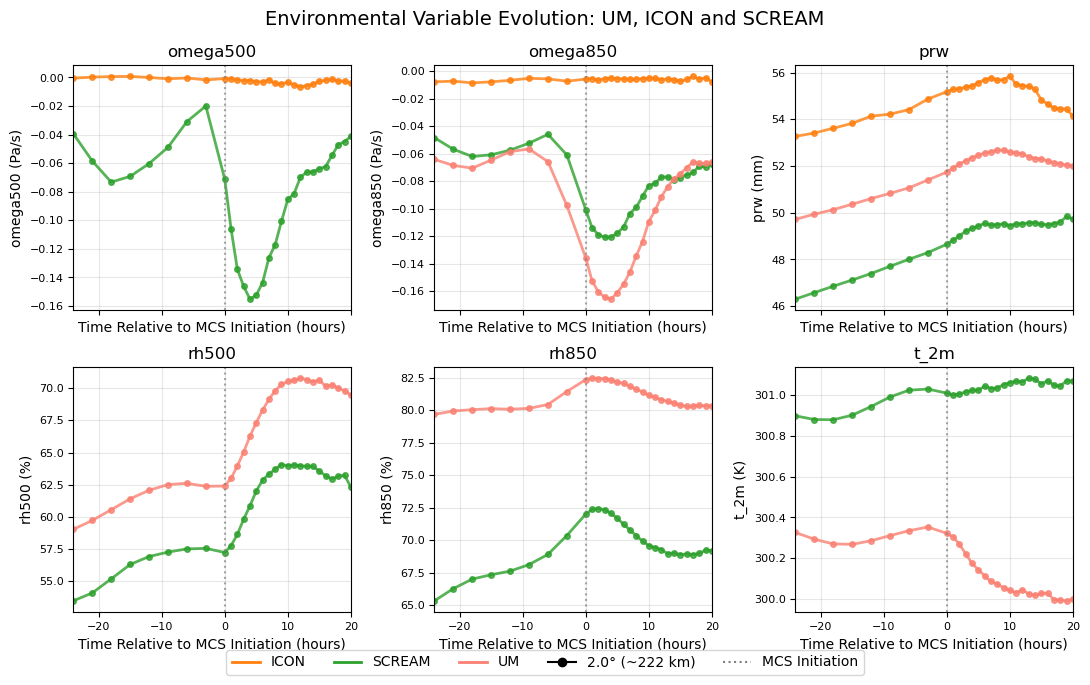

In [53]:
# Example usage:
variable_dfs_dict = {
    # 'ERA5': era5_evolution_dfs,  # Your existing variable DataFrames
    'ICON': evolution_dfs_icon,
    'SCREAM': evolution_dfs_scream,
    'UM': evolution_dfs_um
}

# Call the function
fig = plot_multi_variable_all_comparison(
    variable_dfs_dict,
    radii=[2.0,],time_range=(-24,20),xlimf=20,
    variable_units=variable_units,  # optional
    figsize=(11, 7),
    fontsize=10
)

/var/folders/dl/9_7t7r_952jcx037fn99p7pm0000gn/T/ipykernel_71056/848398283.py:217: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


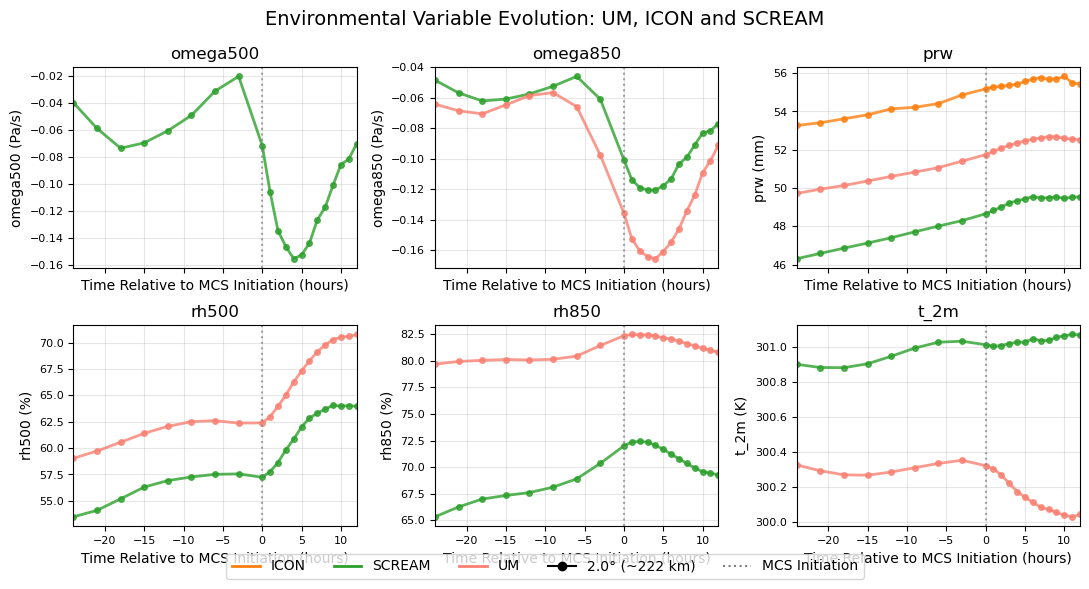

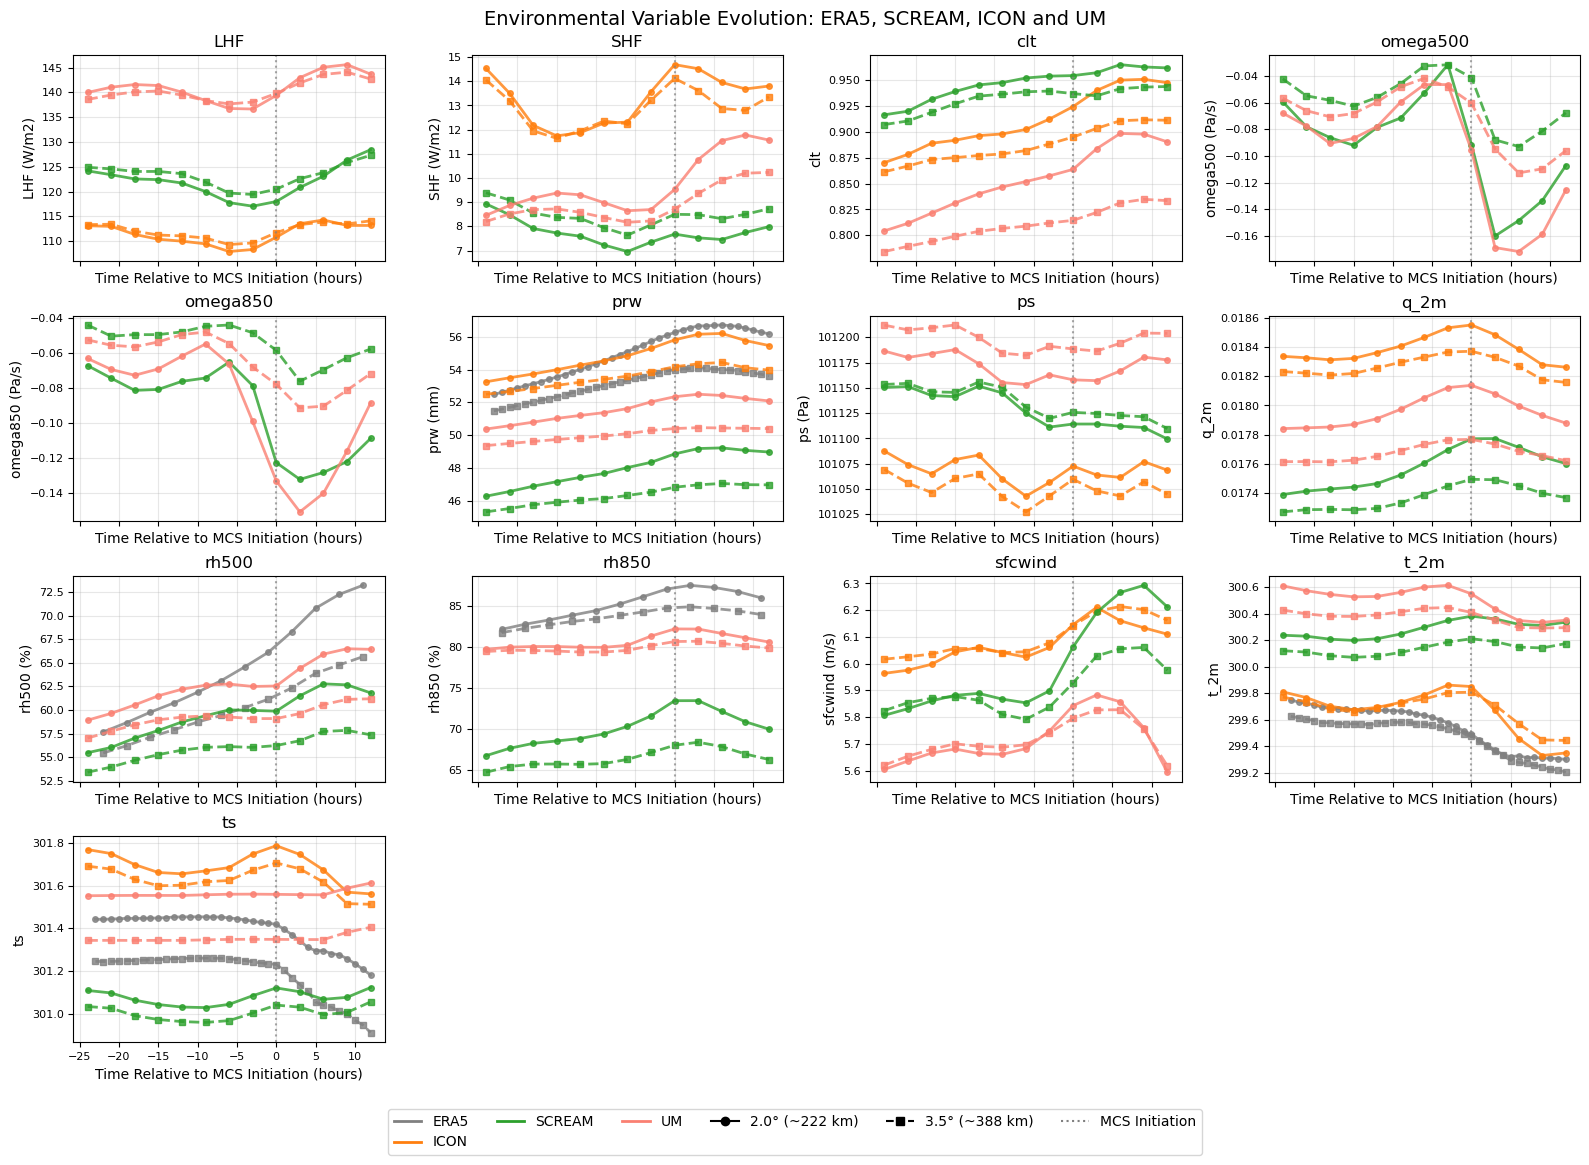

In [39]:
# Example usage:
variable_dfs_dict = {
    'ERA5': era5_evolution_dfs,  # Your existing variable DataFrames
    'ICON': icon_evolution_dfs,
    'SCREAM': scream_evolution_dfs,
    'UM': um_evolution_dfs
}

# Call the function
fig = plot_multi_variable_all_comparison(
    variable_dfs_dict,
    time_range=(-24, 12),
    radii=[2.0, 3.5],
    variable_units=variable_units,  # optional
    figsize=(16, 12),
    fontsize=10
)


plt.savefig('plots/model_era5_environmental_evolution_comparison.png', 
            dpi=300, bbox_inches='tight')

/tmp/ipykernel_2188613/1091758518.py:216: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


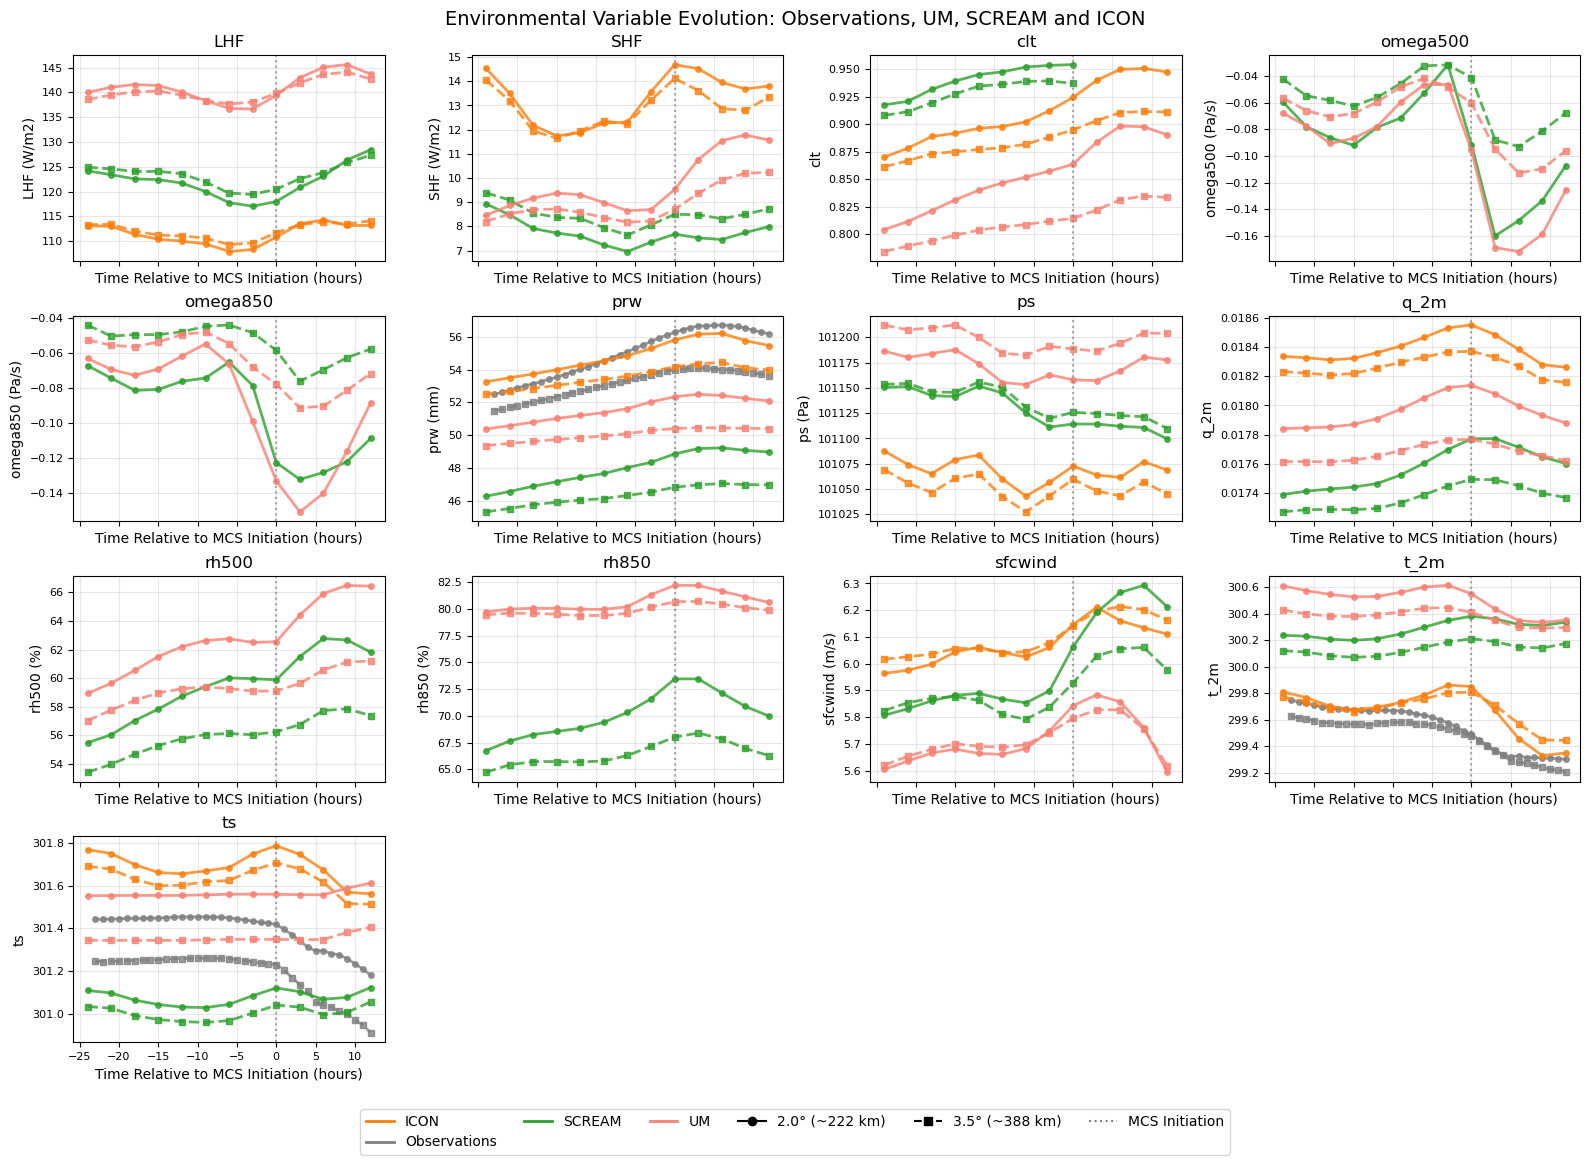

In [189]:
# Example usage:
variable_dfs_dict = {
    'Observations': era5_evolution_dfs,  # Your existing variable DataFrames
    'ICON': icon_evolution_dfs,
    'SCREAM': scream_evolution_dfs,
    'UM': um_evolution_dfs
}

# Call the function
fig = plot_multi_variable_all_comparison(
    variable_dfs_dict,
    time_range=(-24, 12),
    radii=[2.0, 3.5],
    variable_units=variable_units,  # optional
    figsize=(16, 12),
    fontsize=10
)


plt.savefig('plots/model_era5_environmental_evolution_comparison.png', 
            dpi=300, bbox_inches='tight')

In [193]:
def plot_multi_variable_extremes_comparison(extreme_cases_results_dict, 
                                          mcs_feature='track_duration',
                                          radius=2.0, percentile_high=90, percentile_low=10,
                                          nrows=None, ncols=None, figsize=None, 
                                          variable_units=None, share_y=False, fontsize=10):
    """
    Plot extreme cases (high vs low percentiles) for multiple variables across different models/observations.
    
    Parameters:
    -----------
    extreme_cases_results_dict : dict
        Dictionary where keys are model names and values are dictionaries of extreme cases results.
        Each inner dictionary should contain results from get_extreme_cases_data for each variable.
        Example: {
            'Observations': {
                'temp': extreme_data_obs_temp,
                'humidity': extreme_data_obs_humidity, ...
            },
            'ICON': {
                'temp': extreme_data_icon_temp,
                'pressure': extreme_data_icon_pressure, ...
            },
            'SCREAM': {
                'temp': extreme_data_scream_temp, ...
            }
        }
    mcs_feature : str, default='track_duration'
        MCS feature that was used for categorization ('pf_area', 'area', 'track_duration', etc.)
    radius : float, default=2.0
        Radius value that was used for analysis
    percentile_high : int, default=90
        Upper percentile for extreme cases (for labels)
    percentile_low : int, default=10
        Lower percentile for extreme cases (for labels)
    nrows, ncols : int, optional
        Number of rows and columns in the subplot grid
    figsize : tuple, optional
        Figure size (width, height) in inches
    variable_units : dict, optional
        Dictionary mapping variable names to their units for y-axis labels
    share_y : bool, default=False
        Whether to share y-axis limits across all subplots
    fontsize : int, default=10
        Base font size for plot elements
    
    Returns:
    --------
    matplotlib.figure.Figure
        Figure object containing the multi-panel extreme cases comparison plot
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.lines import Line2D
    
    # Define colors for each model (matching your existing color scheme)
    model_colors = {
        'Observations': 'gray', 
        'ICON': '#ff7f0e', 
        'SCREAM': '#2ca02c', 
        'UM': 'salmon'
    }
    
    # Define line styles for extreme cases
    extreme_styles = {
        'high': '-',    # solid line for high percentile
        'low': '--'     # dashed line for low percentile
    }
    
    extreme_markers = {
        'high': 'o',    # circle for high percentile
        'low': 's'      # square for low percentile
    }
    
    # Collect all unique variables across all models
    all_variables = set()
    for model_name, model_results in extreme_cases_results_dict.items():
        all_variables.update(model_results.keys())
    
    all_variables = sorted(all_variables)
    n_vars = len(all_variables)
    
    if n_vars == 0:
        raise ValueError("No variables found in any model")
    
    # Determine grid dimensions
    if nrows is None and ncols is None:
        ncols = int(np.ceil(np.sqrt(n_vars)))
        nrows = int(np.ceil(n_vars / ncols))
    elif nrows is None:
        nrows = int(np.ceil(n_vars / ncols))
    elif ncols is None:
        ncols = int(np.ceil(n_vars / nrows))
    
    # Calculate figure size if not provided
    if figsize is None:
        figsize = (ncols * 4, nrows * 3)
    
    # Create figure and axes grid
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=True, sharey=share_y,
                           constrained_layout=True)
    
    # Flatten axes array for easy iteration if there are multiple subplots
    if n_vars > 1:
        if nrows == 1 and ncols == 1:
            axes = np.array([axes])
        axes_flat = axes.flatten()
    else:
        axes_flat = np.array([axes])
    
    # Track which models we actually plot
    models_plotted = set()
    
    # Process each variable
    for i, var_name in enumerate(all_variables):
        if i >= len(axes_flat):
            print(f"Warning: More variables than subplot space. Skipping {var_name}.")
            continue
        
        ax = axes_flat[i]
        variable_has_data = False
        
        # Process each model for this variable
        for model_name, model_results in extreme_cases_results_dict.items():
            # Check if this model has this variable
            if var_name not in model_results:
                continue
            
            extreme_data = model_results[var_name]
            
            # Get color for this model
            model_color = model_colors.get(model_name, 'black')
            
            # Plot high and low percentiles
            try:
                high_data = extreme_data['high_data']
                low_data = extreme_data['low_data']
                threshold_high = extreme_data['threshold_high']
                threshold_low = extreme_data['threshold_low']
                
                # Plot high percentile
                if len(high_data) > 0 and not high_data['mean'].isna().all():
                    variable_has_data = True
                    models_plotted.add(model_name)
                    
                    label_high = f'{model_name} - Top {100-percentile_high}% ({threshold_high:.1f})'
                    
                    ax.plot(high_data['time_bin_center'], high_data['mean'],
                           linestyle=extreme_styles['high'],
                           marker=extreme_markers['high'],
                           color=model_color,
                           linewidth=2,
                           markersize=4,
                           alpha=0.8,
                           label=label_high)
                
                # Plot low percentile
                if len(low_data) > 0 and not low_data['mean'].isna().all():
                    variable_has_data = True
                    models_plotted.add(model_name)
                    
                    label_low = f'{model_name} - Bottom {percentile_low}% ({threshold_low:.1f})'
                    
                    ax.plot(low_data['time_bin_center'], low_data['mean'],
                           linestyle=extreme_styles['low'],
                           marker=extreme_markers['low'],
                           color=model_color,
                           linewidth=2,
                           markersize=4,
                           alpha=0.8,
                           label=label_low)
                
            except Exception as e:
                print(f"Warning: Could not process {model_name} - {var_name}: {e}")
                continue
        
        # Only format the subplot if we have data
        if variable_has_data:
            # Add vertical line at time = 0
            ax.axvline(x=0, color='gray', linestyle=':', alpha=0.7)
            
            # Add labels and title
            ax.set_xlabel('Time Relative to MCS Initiation (hours)', fontsize=fontsize)
            if variable_units and var_name in variable_units:
                ax.set_ylabel(f'{var_name} ({variable_units[var_name]})', fontsize=fontsize)
            else:
                ax.set_ylabel(var_name, fontsize=fontsize)
            
            ax.set_title(var_name, fontsize=fontsize+2)
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='both', which='major', labelsize=fontsize-2)
        else:
            # If no data, hide the subplot
            ax.set_visible(False)
    
    # Remove empty subplots
    for i in range(n_vars, len(axes_flat)):
        axes_flat[i].set_visible(False)
    
    # Add a main title for the entire figure
    model_names = list(models_plotted)
    if len(model_names) > 2:
        title_models = ', '.join(model_names[:-1]) + f' and {model_names[-1]}'
    else:
        title_models = ' vs '.join(model_names)
    
    feature_desc = mcs_feature.replace('_', ' ').title()
    fig.suptitle(f'Extreme {feature_desc} Cases: {title_models} (Radius = {radius}°)', 
                fontsize=fontsize+4, y=0.98)
    
    # Create a comprehensive legend at the bottom
    legend_elements = []
    
    # Add model color legend (only for models that were actually plotted)
    for model_name in sorted(models_plotted):
        legend_elements.append(
            Line2D([0], [0], color=model_colors.get(model_name, 'black'), 
                   linewidth=2, label=model_name)
        )
    
    # Add extreme case style legend
    legend_elements.extend([
        Line2D([0], [0], color='black', linestyle=extreme_styles['high'], 
               marker=extreme_markers['high'], 
               label=f'Top {100-percentile_high}% {feature_desc}'),
        Line2D([0], [0], color='black', linestyle=extreme_styles['low'], 
               marker=extreme_markers['low'], 
               label=f'Bottom {percentile_low}% {feature_desc}')
    ])
    
    # Add initiation line
    legend_elements.append(Line2D([0], [0], color='gray', linestyle=':', 
                                 label='MCS Initiation'))
    
    # Calculate number of columns for legend
    ncol_legend = min(len(legend_elements), 6)  # Max 6 columns
    
    fig.legend(handles=legend_elements, loc='lower center', 
              bbox_to_anchor=(0.5, 0.02), ncol=ncol_legend, fontsize=fontsize)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)  # Make room for the legend
    
    return fig

In [ ]:
# Example usage:
variable_dfs_dict = {
    'Observations': variable_dfs_obs,  # Your existing variable DataFrames
    'ICON': variable_dfs_icon,
    'SCREAM': variable_dfs_scream,
    'UM': variable_dfs_um
}


In [ ]:
# Your existing workflow for each model/observation
# For example, for observations:
extreme_intensity_cases_results_obs = {}
for var_name, df in var_dfs_obs.items():
    print(f"Processing Observations {var_name}...")
    extreme_data = get_extreme_cases_data(
        df,
        mcs_feature=mcs_feature,
        stat_var='mean',
        radius=radius,
        percentile_high=percentile_high,
        percentile_low=percentile_low,
        time_range=time_range
    )
    extreme_intensity_cases_results_obs[var_name] = extreme_data

# Similarly for ICON
extreme_intensity_cases_results_icon = {}
for var_name, df in var_dfs_icon.items():
    print(f"Processing ICON {var_name}...")
    extreme_data = get_extreme_cases_data(
        df,
        mcs_feature=mcs_feature,
        stat_var='mean',
        radius=radius,
        percentile_high=percentile_high,
        percentile_low=percentile_low,
        time_range=time_range
    )
    extreme_intensity_cases_results_icon[var_name] = extreme_data

# Similarly for ICON
extreme_intensity_cases_results_scream = {}
for var_name, df in var_dfs_scream.items():
    print(f"Processing ICON {var_name}...")
    extreme_data = get_extreme_cases_data(
        df,
        mcs_feature=mcs_feature,
        stat_var='mean',
        radius=radius,
        percentile_high=percentile_high,
        percentile_low=percentile_low,
        time_range=time_range
    )
    extreme_intensity_cases_results_scream[var_name] = extreme_data

# Similarly for ICON
extreme_intensity_cases_results_um = {}
for var_name, df in var_dfs_um.items():
    print(f"Processing UM {var_name}...")
    extreme_data = get_extreme_cases_data(
        df,
        mcs_feature=mcs_feature,
        stat_var='mean',
        radius=radius,
        percentile_high=percentile_high,
        percentile_low=percentile_low,
        time_range=time_range
    )
    extreme_intensity_cases_results_um[var_name] = extreme_data
    
# Then combine all results into the dictionary format needed
extreme_cases_results_dict = {
    'Observations': extreme_intensity_cases_results_obs,
    'ICON': extreme_intensity_cases_results_icon,
    'SCREAM': extreme_intensity_cases_results_scream,
    'UM': extreme_intensity_cases_results_um
}

# Call the comparison function
fig = plot_multi_variable_extremes_comparison(
    extreme_cases_results_dict,
    mcs_feature=mcs_feature,
    radius=radius,
    percentile_high=percentile_high,
    percentile_low=percentile_low,
    variable_units={'temp': '°C', 'humidity': '%', 'pressure': 'hPa'},  # optional
    figsize=(16, 12),
    fontsize=10
)

plt.show()

/tmp/ipykernel_2188613/3676359987.py:239: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


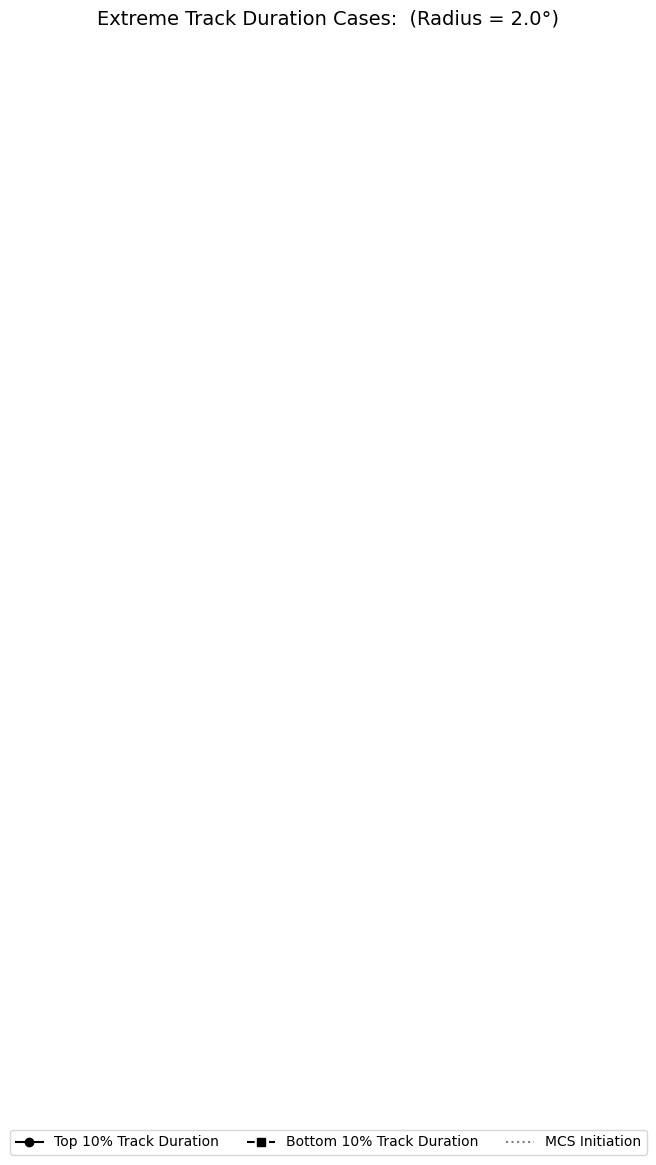

In [191]:

# Call the function
fig = plot_multi_variable_extremes_comparison(
    variable_dfs_dict,
    mcs_feature='track_duration',  # or 'pf_area', 'area', etc.
    radius=2.0,
    percentile_high=90,
    percentile_low=10,
    time_range=(-24, 24),
    time_bin_size=3,
    variable_units=variable_units,
    figsize=(16, 12),
    fontsize=10
)

plt.show()

/tmp/ipykernel_2188613/1091758518.py:216: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


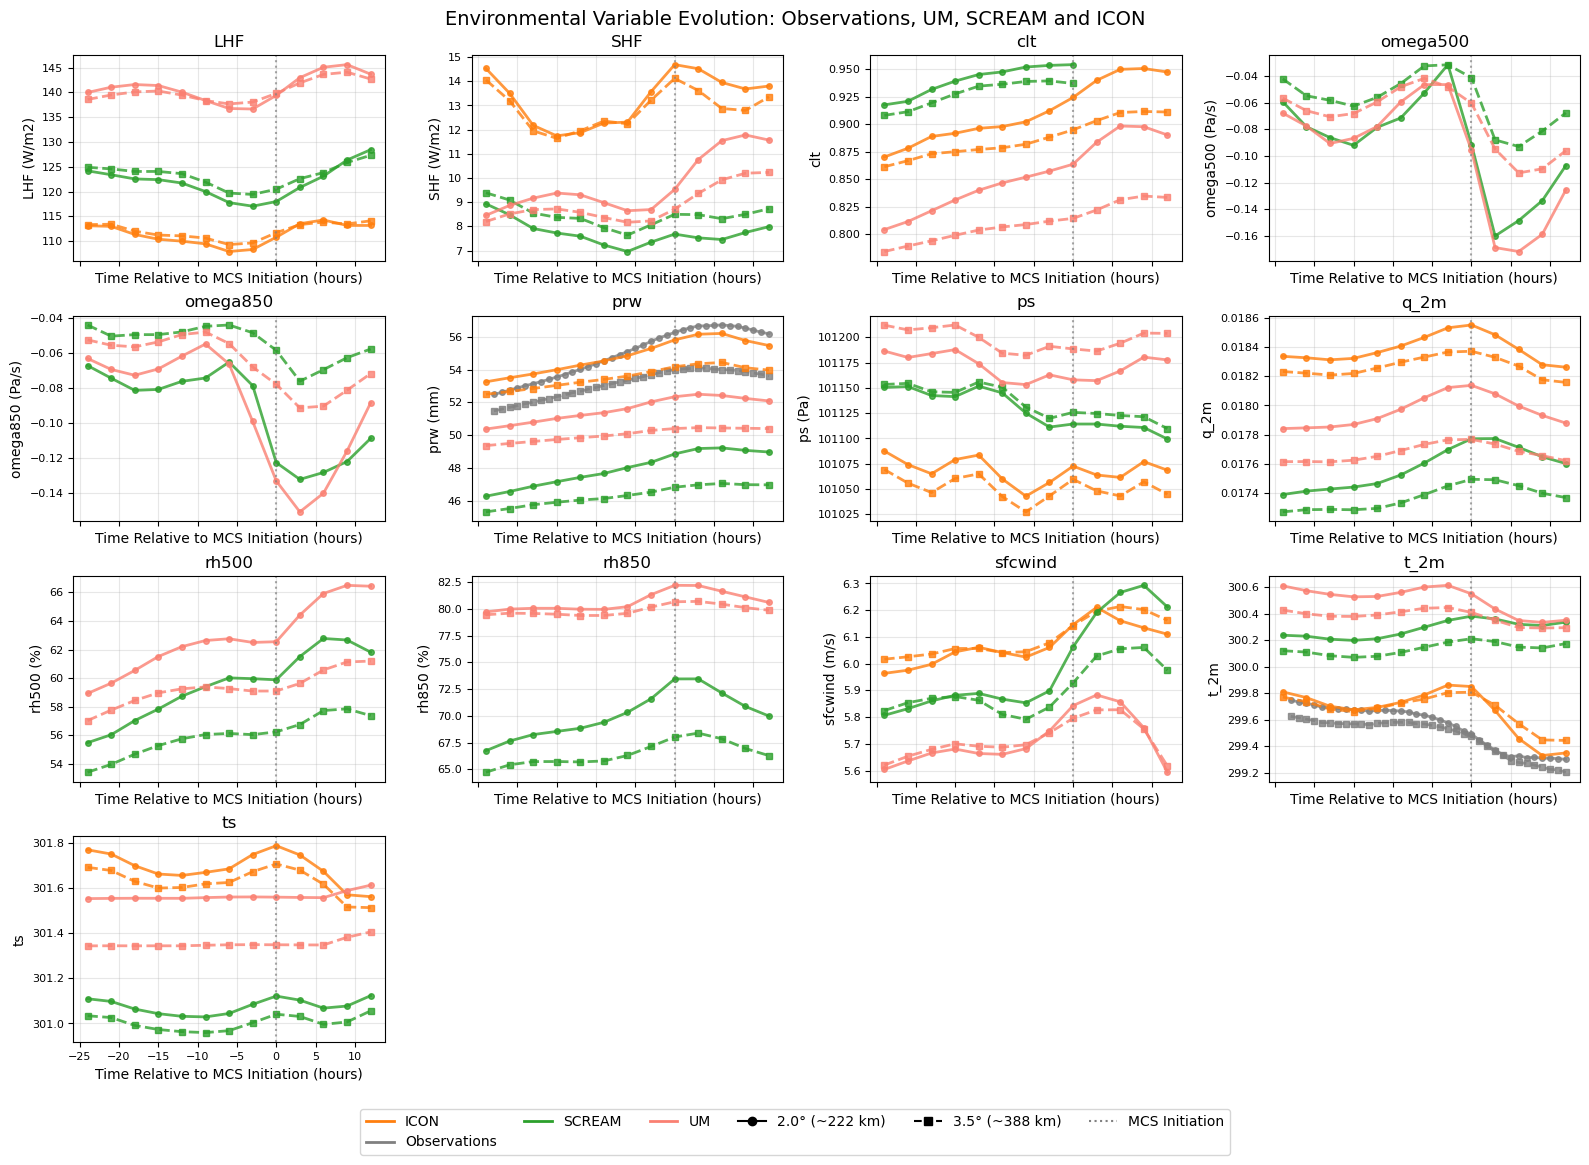

/global/cfs/cdirs/wcm_code/lpaccini/scripts/hackathon/tools_mcs_stats.py:740: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


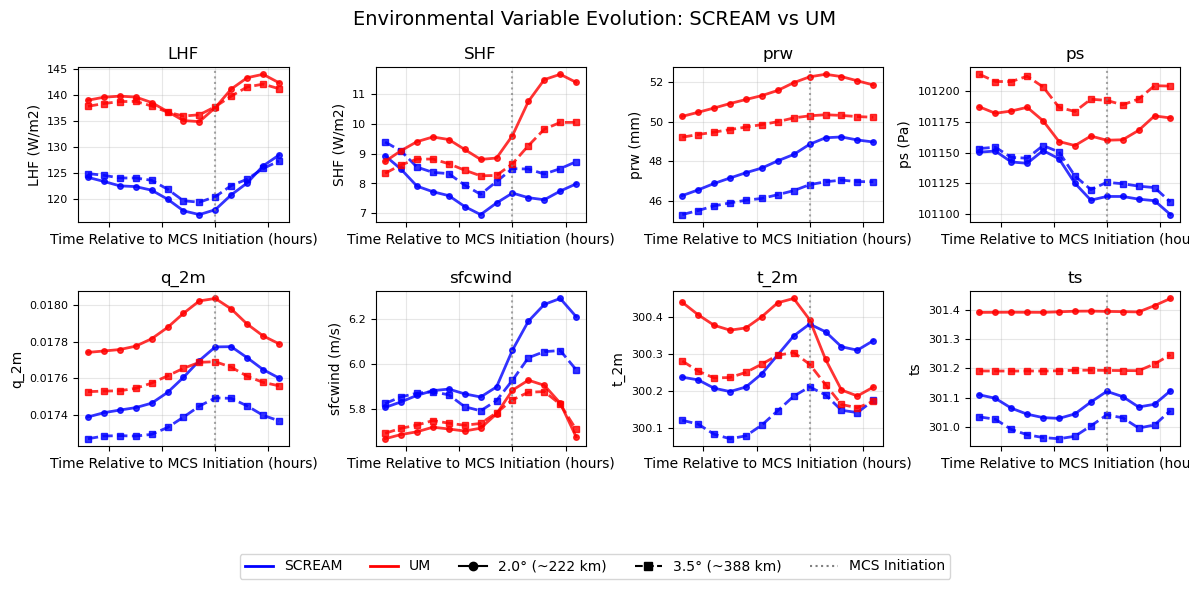

In [125]:
# Create the comparison plot using only radii 2.0 and 3.5
fig = plot_multi_variable_model_comparison(
    scream_evolution_dfs,  # Your SCREAM data (already processed)
    um_evolution_dfs,  # ICON data (needs to be processed as shown above)
    model1_label="SCREAM",
    model2_label="UM",
    nrows=3, 
    ncols=4,
    figsize=(12, 6),
    time_range=(-24, 12),
    radii=[2.0, 3.5],  # Only these two radii
    variable_units=variable_units,
    fontsize=10
)

plt.savefig('plots/scream_vs_um_environmental_evolution_comparison.png', 
            dpi=300, bbox_inches='tight')

/tmp/ipykernel_1670424/1134052482.py:176: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


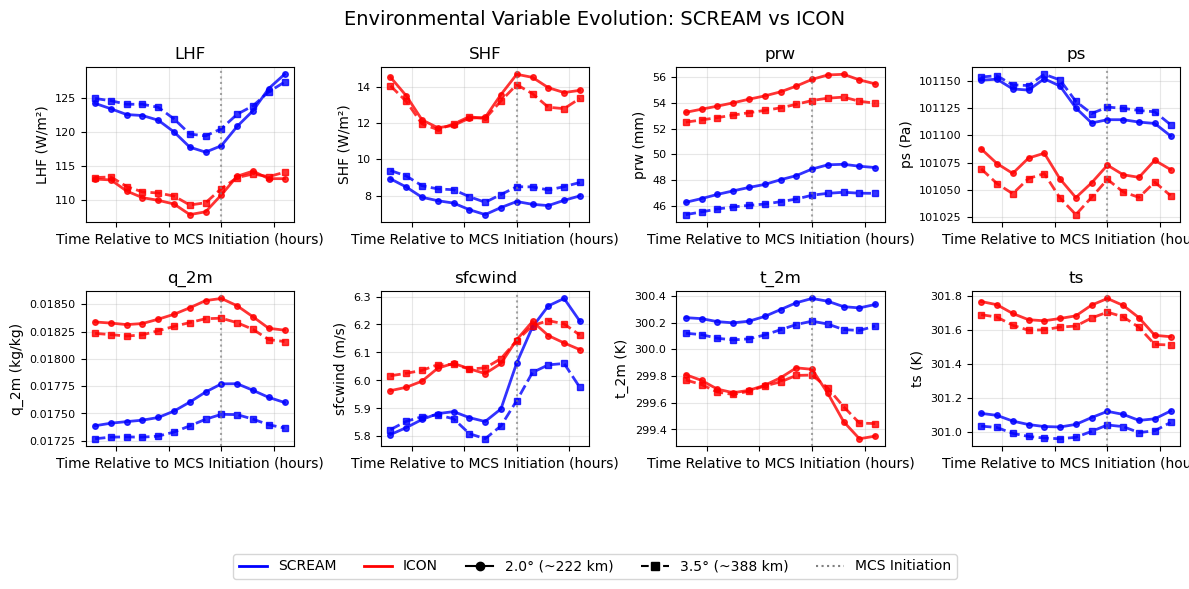

In [111]:

# plt.savefig('plots/scream_vs_icon_environmental_evolution_comparison.png', 
#             dpi=300, bbox_inches='tight')
# plt.show()

In [85]:
def calculate_significance(extreme_cases_results):
    """Calculate statistical significance of differences between high and low categories"""
    significance_results = {}
    
    for var_name, result in extreme_cases_results.items():
        high_df = result['high_data']
        low_df = result['low_data']
        
        # Merge on time bin center
        merged = pd.merge(high_df, low_df, on='time_bin_center', 
                         suffixes=('_high', '_low'))
        
        # Calculate difference and p-values
        merged['difference'] = merged['mean_high'] - merged['mean_low']
        
        # We don't have individual data points for proper t-test, 
        # but we can calculate if difference > combined std
        merged['combined_std'] = np.sqrt(merged['std_high']**2 + merged['std_low']**2)
        merged['significant'] = abs(merged['difference']) > merged['combined_std']
        
        significance_results[var_name] = merged
    
    return significance_results

# Calculate significance
significance = calculate_significance(extreme_cases_results)

# Print significant differences
for var_name, result in significance.items():
    sig_times = result[result['significant']]['time_bin_center'].tolist()
    if sig_times:
        print(f"{var_name}: Significant differences at times {sig_times}")

In [86]:
# Create a summary of maximum differences
max_diff_summary = []

for var_name, result in significance.items():
    # Find maximum absolute difference 
    idx_max = result['difference'].abs().idxmax()
    max_row = result.loc[idx_max]
    
    max_diff_summary.append({
        'variable': var_name,
        'time': max_row['time_bin_center'],
        'diff': max_row['difference'],
        'abs_diff': abs(max_row['difference']),
        'significant': max_row['significant'],
        'high_mean': max_row['mean_high'],
        'low_mean': max_row['mean_low']
    })

# Convert to DataFrame and sort by absolute difference
diff_df = pd.DataFrame(max_diff_summary).sort_values('abs_diff', ascending=False)
print(diff_df)

    variable  time        diff    abs_diff  significant      high_mean  \
6         ps -19.5 -209.348116  209.348116        False  101011.107905   
0        LHF -16.5   -7.370827    7.370827        False     120.054984   
4        SHF   1.5    3.252782    3.252782        False       9.553598   
3        prw -22.5    1.221607    1.221607        False      46.043982   
2    sfcwind -19.5   -0.878663    0.878663        False       5.436982   
5   t_2m_avg -19.5    0.394633    0.394633        False     300.292844   
10  omega500  10.5   -0.057301    0.057301        False      -0.142067   
8      rh500   4.5   -0.048567    0.048567        False       0.583337   
9   omega850  10.5   -0.033004    0.033004        False      -0.131821   
7      rh850 -19.5    0.008042    0.008042        False       0.676816   
1   q_2m_avg   7.5    0.000182    0.000182        False       0.017626   

         low_mean  
6   101220.456021  
0      127.425811  
4        6.300816  
3       44.822376  
2        6.